In [1]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
import numba as nb
import time
import importlib
import json
import argparse
import h5py
from matplotlib import pyplot as plt
from datetime import datetime as dt

from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils

from scipy.optimize import minimize,check_grad,least_squares
from scipy.ndimage import median_filter 
from skyfield.api import load, wgs84

import fitting_helper as fh
import figures as fgs
import mohan_timing as mt


sys.path.append(os.path.expanduser('~'))

BDC is using numpy
BDC is using numpy


In [2]:
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

@nb.njit()
def func(tau_t, data, freq, weights):
    ''' 
    Get residuals for given tau at single time sample, for all blines

    Notes:
    - we set the reference antenna to zero delay: all other ants are with respect to it
    - therefore tau_t has length nant-1
    - residuals is 1D, and splits real and imag residuals up for fitting
    - convention is that timing difference is ai-aj
    '''
    # for one time sample
    nant=6
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    residuals = np.zeros((2 * n_eval,), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * freq[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                y = np.exp(1j * pred) - np.exp(1j*data[rowidx])
                residuals[rowidx] = w * np.real(y)
                residuals[rowidx + n_eval] = w * np.imag(y)
                blnum += 1
    return residuals

@nb.njit()
def jac(tau_t, data, freq, weights):
    '''
    Get the Jacobian for given tau at single time sample, for all blines

    Notes:
    - Antenna 0 is the reference so its delay is zero
    - therefore tau_t has length nant-1
    '''
    nant=6
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    J = np.zeros((2 * n_eval, nant-1), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * freq[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, aj - 1] = -im
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, ai - 1] = re
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, ai - 1] = im
                    J[rowidx + n_eval, aj - 1] = -im
                blnum += 1
    return J

In [3]:
path_config = "/home/thomasb/albatros_analysis/scripts/orbcomm/config/config_batch2.json"

with open(path_config, "r") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
        antpos.append(details["coordinates"])
print(antpos)

batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
osamp = config['correlation']['osamp']
acclen = config['correlation']['new_acclen']

T_SPECTRA = 4096/250e6 * osamp
print(T_SPECTRA)

[[79.41717895, -90.76721818, 188.095], [79.41721848, -90.75872502, 183.51076468], [79.38845797, -91.01936185, 19.777], [79.4183154, -90.667425, 59.364], [79.3979952, -90.799868, 42.692], [79.41148497, -90.69528512, 32.593], [79.44377162, -90.71824306, 416.829]]
0.001048576


In [4]:
path_batch = f'/scratch/thomasb/batch_{batch_start_ts}'

fname_pulses = "data/pulses2.json"
path_pulses = os.path.join(path_batch, fname_pulses)
fname_cutter = "timing_discrepancies/cutting.json"
path_cutter = os.path.join(path_batch, fname_cutter)
fname_map = 'timing_discrepancies/times_all_incoherent.json'
path_map = os.path.join(path_batch, fname_map)

In [5]:
with open(path_pulses, "r") as f_pulses:
        pulse_list = json.load(f_pulses)
with open(path_cutter, "r") as f_cutter:
        cutter_dict = json.load(f_cutter)
with open(path_map, "r") as f_map:
        map_dict = json.load(f_map)

In [6]:
taus_fitted_all = {}
overflow = False

In [7]:
idx_pulse = 1

#extract from pulses json
pulse = pulse_list[idx_pulse]
print(pulse)

pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']
print('detection channel', chan_det)

ant_idxs = [0, 2, 3, 4, 5, 6]
ant_nums = [1, 2, 4, 5, 6, 7, 8]

if chan_det%2 == 0:
    chans_old = np.arange(chan_det-2, chan_det+2) + 1834
else:
    chans_old = np.arange(chan_det-1, chan_det+3) + 1834

print(chans_old)

{'antenna': 'Antenna 2', 'sat': 57166, 'channel': 3, 't_start': 1753204614, 't_end': 1753204859, 'len': 245}
detection channel 3
[1836 1837 1838 1839]


In [8]:
fname_data = f"data_raw_osamp=64_start={pulse_start_ts}_end={pulse_end_ts}_chans={chans_old[0]}:{chans_old[-1]}.npy"

#extract from cutter json
cut = cutter_dict[fname_data]

chan_new_start, chan_new_end  = cut["new_chans"]
chans_new = np.arange(chan_new_start, chan_new_end)
nchans = len(chans_new)
print(nchans)
print(chans_new)

data_all = np.load(os.path.join(path_batch, 'data', fname_data))
data_all = data_all[:, :, :, chans_new]
print(data_all.shape)

80
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79]
(7, 2, 233472, 80)


In [9]:
#extract from mapping json
map = map_dict[fname_data]
overflow = False
#pulse_start_spec = map["start_spectrum"] 

pulse_start_spec = map["start_spectrum"]
# if overflow==True:
#     pulse_start_spec+=2**32
print('starting specnum', pulse_start_spec)

spec_per_UTC = 1.638400946109685e-05
UTC_offset = 1753200128.469018

pstart_init = spec_per_UTC*pulse_start_spec + UTC_offset
print(pstart_init)

tle_path = outils.get_tle_file(pstart_init, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

freqs = (chans_new/64 + chans_old[0])*250e6/4096
freqs = 250e6-freqs

#print(freqs)
#print(freqs.shape)

starting specnum 273770916
1753204613.934296


In [10]:
cut_start, cut_end = 70, 170
spectra_cut_start= 1024*cut_start
spectra_cut_end = 1024*cut_end
print(spectra_cut_start)
print(spectra_cut_end)

pulse_start_spec_cut = pulse_start_spec+spectra_cut_start*64
pulse_start_fitted = spec_per_UTC*pulse_start_spec_cut + UTC_offset
print(pulse_start_fitted)

data = data_all[:,:,spectra_cut_start:spectra_cut_end,:]
print(data.shape)

71680
174080
1753204689.096267
(7, 2, 102400, 80)


In [11]:
n_blines = len(ant_idxs)*(len(ant_idxs)-1)//2

multi_vis = np.zeros((n_blines, data.shape[2]//acclen, data.shape[3]), dtype='complex64', order='c')
print("multi_vis shape", multi_vis.shape)

bl_proc=0
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            a1_coords=antpos[ai]
            a2_coords=antpos[aj]
            dly = outils.get_sat_delay(
                                a1_coords,
                                a2_coords,
                                tle_path,
                                pulse_start_fitted,
                                int(pulse_end_ts - pulse_start_fitted)+2,  #BEWARE maybe the fitting messed this up
                                satID,
                                altaz=False
                            )
            delay = np.interp(
                np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(pulse_end_ts - pulse_start_fitted)+2), dly
            )
            spec1=data[ai,0,:,:]
            spec2=data[aj,0,:,:]
            spec2_phased = np.empty_like(spec2)
            # print("spec2", spec2_phased.shape)
            # print(spec2_phased.flags)
            spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
            Vxx = xcorr_avg(spec1,spec2_phased,acclen)
            spec1=data[ai,1,:,:]
            spec2=data[aj,1,:,:]
            spec2_phased = np.empty_like(spec2)
            spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
            Vyy = xcorr_avg(spec1,spec2_phased,acclen)
            multi_vis[bl_proc,:,:] = (Vxx+Vyy)/2
            bl_proc+=1
            print("done", ai,aj,".Processed",bl_proc, "baselines")

multi_vis shape (15, 100, 80)
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.09460186958312988
done 0 2 .Processed 1 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.0916452407836914
done 0 3 .Processed 2 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.09403729438781738
done 0 4 .Processed 3 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.09791874885559082
done 0 5 .Processed 4 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.1456291675567627
done 0 6 .Processed 5 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.09283137321472168
done 2 3 .Processed 6 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.09014081954956055
done 2 4 .Processed 7 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.09087920188903809
done 2 5 .Processed 8 baselines
catalog #57166 epoch

15
(15, 100, 80)


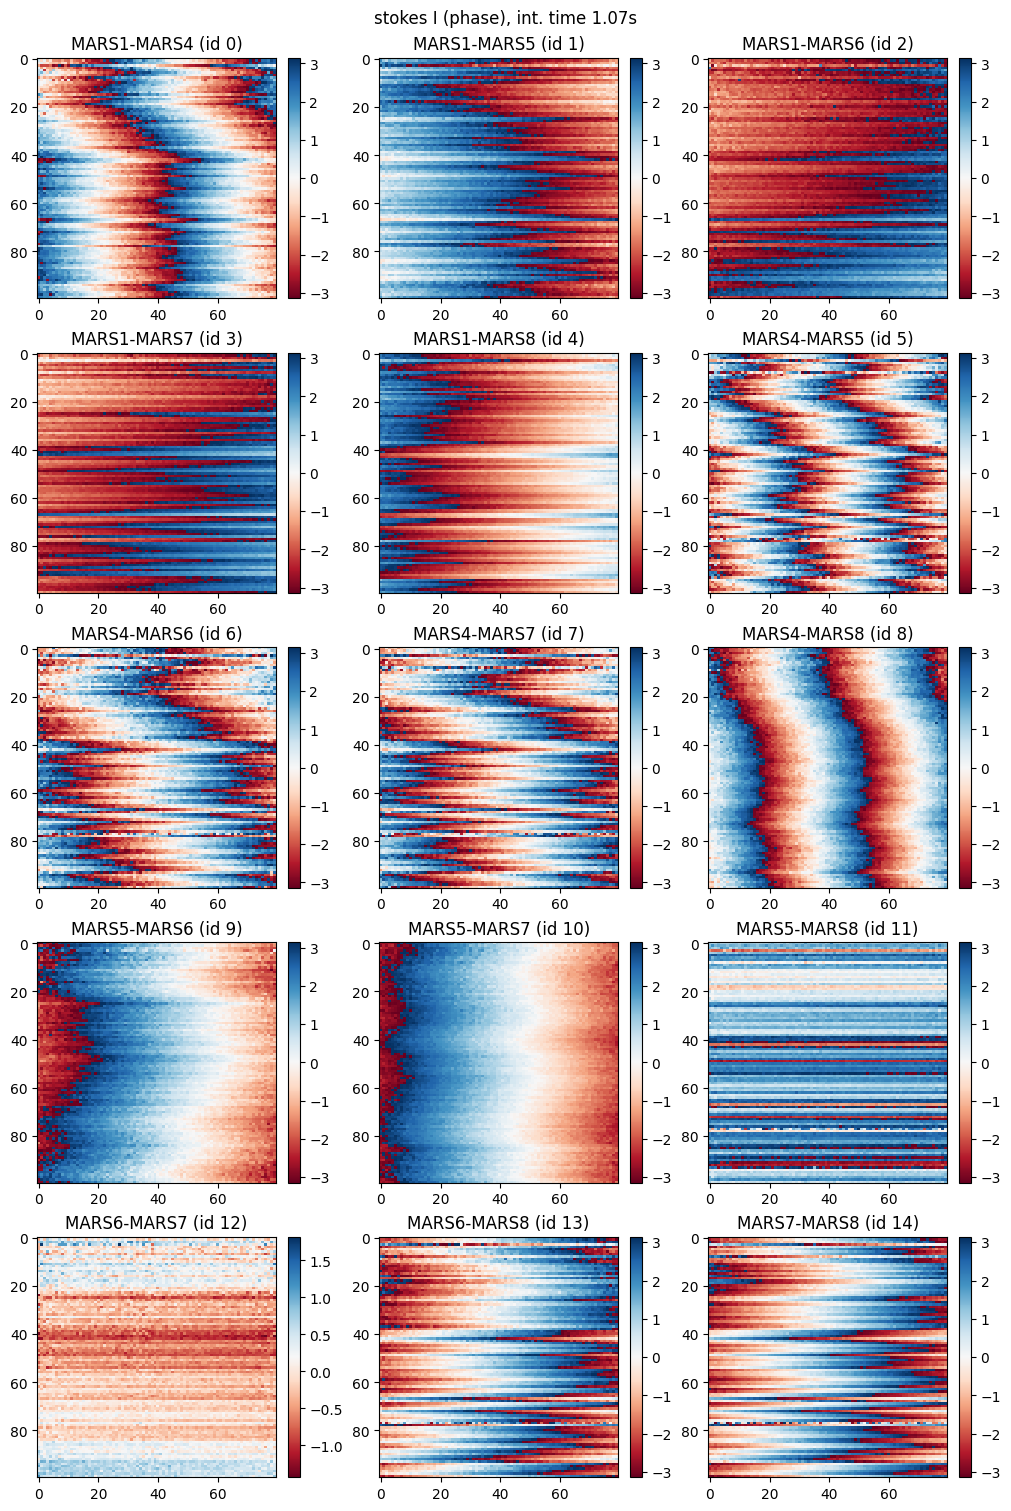

In [12]:
#generate phase plots for each baseline
nant=7
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(5,3, constrained_layout=True)
fig.set_size_inches(10,15)
ax=np.ravel(ax)
pnum=0
print(n_blines)
plt.suptitle(f"stokes I (phase), int. time {T_SPECTRA*acclen:4.2f}s")
x = np.arange(data.shape[3])
thermal_noise = np.zeros((n_blines, multi_vis.shape[1]),dtype='float64')
vis_noise = np.zeros((n_blines, multi_vis.shape[1]),dtype='float64')
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            ax[pnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {pnum})")
            a=np.unwrap(np.angle(multi_vis[pnum,:,:]),axis=1)
            for k in range(a.shape[0]):
                m, c = np.polyfit(x, a[k,:], 1)
                residual = a[k,:] - (m*x + c)
                # sigma_phi = np.sqrt(np.mean(residual**2))
                sigma_phi = np.std(np.angle(np.exp(1j*residual)))
                thermal_noise[pnum,k] = sigma_phi
                vis_noise[pnum,k] = np.std(np.cos(residual))
            b=np.unwrap(a,axis=0)
            img=ax[pnum].imshow(np.angle(multi_vis[pnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
            cbar=plt.colorbar(img,ax=ax[pnum])
            #ax[pnum].set_ylim(cut_end, cut_start)
            pnum+=1
# plt.tight_layout()
print(multi_vis.shape)

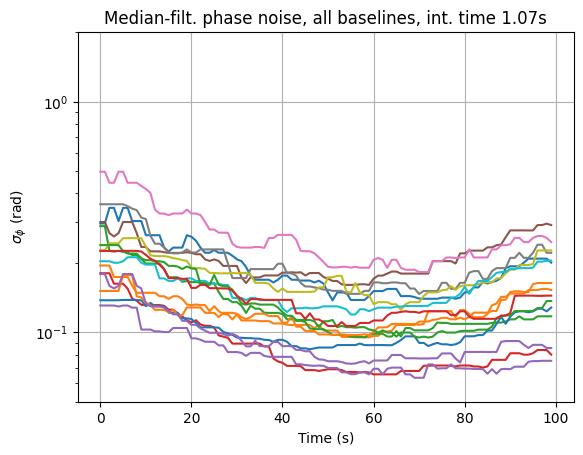

In [13]:
for bl in range(n_blines):
    plt.semilogy(median_filter(thermal_noise[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

In [14]:
path_cutter_finetiming = os.path.join(path_batch, 'cutting_finetiming.json')

if os.path.exists(path_cutter_finetiming):
    with open(path_cutter_finetiming, "r") as f:
        cutter = json.load(f)
else:
    cutter = {}

cutter.setdefault(fname_data, {})
cutter[fname_data]['spectra_start'] = spectra_cut_start
cutter[fname_data]['spectra_end'] = spectra_cut_end

with open(path_cutter_finetiming, "w") as f:
    json.dump(cutter, f, indent=4)

(15, 100)
phase shape (15, 100, 80)
data_matrix shape (100, 80, 15)
weight_matrix shape (100, 15)
noise matrix shape (100, 15)
nant,nfreq,ntime,nbl 6 80 100 15


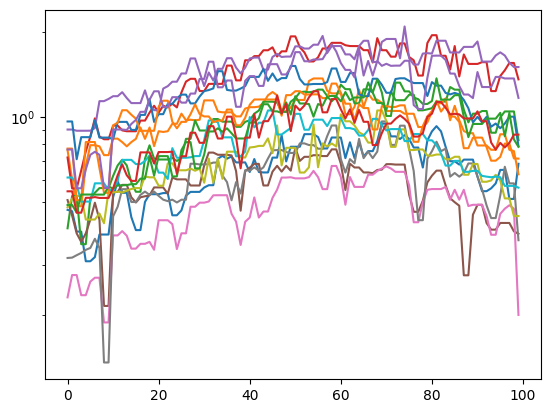

In [15]:
#--without cut
noise_var = median_filter(thermal_noise[:,:],3,axes=1)**2
#--with cut
#noise_var = median_filter(thermal_noise[:,cut_start:cut_end],3,axes=1)**2
print(noise_var.shape)

# noise_var = median_filter(vis_noise[:],2,axes=1)**2
# noise_var = thermal_noise[:]**2
weights = np.sqrt(np.size(noise_var)/noise_var/np.sum(1/noise_var))

for bl in range(n_blines):
    plt.semilogy(weights[bl,:],label=f'bl id {bl}')
#plt.legend()

#--without cut
phase = np.angle(multi_vis[:, :, :])
#--with cut
#phase = np.angle(multi_vis[:, cut_start:cut_end, :])

phase = np.unwrap(phase,axis=2)
phase = np.unwrap(phase,axis=1)
print('phase shape', phase.shape)

#make baseline fastest moving axis for convenience
data_matrix = phase.transpose(1,2,0).copy()
noise_matrix = noise_var.T.copy()
weight_matrix = weights.T.copy()
print('data_matrix shape', data_matrix.shape)
print('weight_matrix shape', weight_matrix.shape)
print('noise matrix shape', noise_matrix.shape)

# make frequencies order 1 for fitting purposes
freqs_normalized = freqs.copy()/1e9

# set up some global variables
assert nchans == data_matrix.shape[1]
ntime = data_matrix.shape[0]
nant = len(ant_idxs)

print("nant,nfreq,ntime,nbl", nant,nchans,ntime,n_blines)

6


done tt=0, time = 0.724
done tt=1, time = 0.013
done tt=2, time = 0.024
done tt=3, time = 0.035
done tt=4, time = 0.016
done tt=5, time = 0.013
done tt=6, time = 0.019
done tt=7, time = 0.013
done tt=8, time = 0.023
done tt=9, time = 0.009
done tt=10, time = 0.010
done tt=11, time = 0.005
done tt=12, time = 0.010
done tt=13, time = 0.005
done tt=14, time = 0.008
done tt=15, time = 0.017
done tt=16, time = 0.007
done tt=17, time = 0.014
done tt=18, time = 0.006
done tt=19, time = 0.014
done tt=20, time = 0.009
done tt=21, time = 0.012
done tt=22, time = 0.020
done tt=23, time = 0.023
done tt=24, time = 0.014
done tt=25, time = 0.038
done tt=26, time = 0.020
done tt=27, time = 0.015
done tt=28, time = 0.012
done tt=29, time = 0.013
done tt=30, time = 0.015
done tt=31, time = 0.023
done tt=32, time = 0.016
done tt=33, time = 0.015
done tt=34, time = 0.017
done tt=35, time = 0.019
done tt=36, time = 0.019
done tt=37, time = 0.021
done tt=38, time = 0.017
done tt=39, time = 0.028
done tt=40

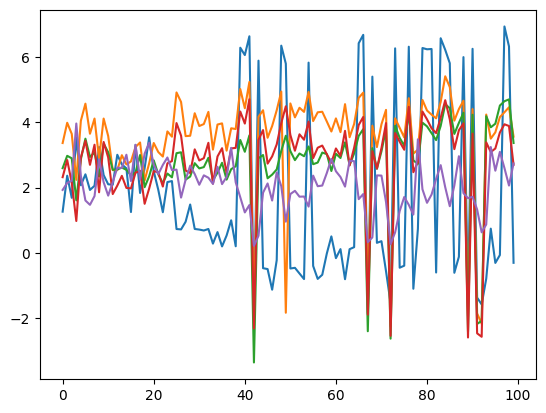

In [16]:
# array of fitted taus for each time, for each (non-reference) antenna
taus_fitted = np.zeros((ntime,nant-1),dtype='float64')
print(nant)

# make some guess about fitted taus (for one sample time)
taus_guess_single = np.ones(nant-1)

for tt in range(ntime):
    ydata = data_matrix[tt,:,:].ravel()
    weights = weight_matrix[tt,:]
    t1=time.time()
    tau_fit_params = least_squares(func, taus_guess_single, args=(ydata, freqs_normalized, weights),
                                                        jac=jac,
                                                        method='lm',
                                                        ftol=1e-06, 
                                                        xtol=1e-06, 
                                                        gtol=1e-06, 
                                                        loss='linear')
    t2=time.time()
    taus_fitted[tt,:] = tau_fit_params['x']
    #print(fit_params)
    print(f"done tt={tt}, time = {t2-t1:5.3f}")
    
plt.plot(taus_fitted)

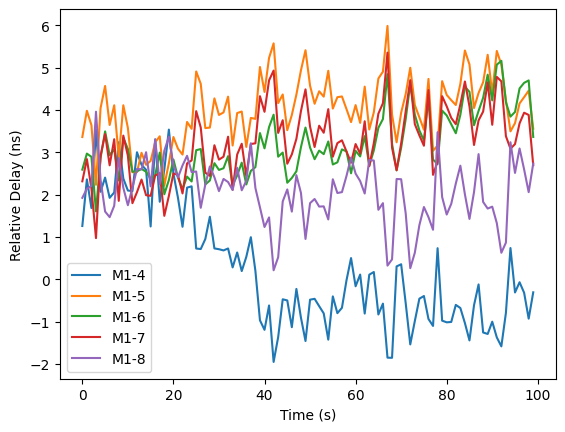

In [17]:
# unwrap the fitted taus into actual delay values
labels=['M1-4', 'M1-5', 'M1-6', 'M1-7', 'M1-8']
taus_unwrapped = np.unwrap(np.angle(np.exp(1j*taus_fitted.reshape(-1,nant-1)*2*np.pi*freqs_normalized.mean())),axis=0)/(2*np.pi*freqs_normalized.mean())

# plot the relative delays of the other antenna with respect to the reference antenna
plt.plot(taus_unwrapped[:,:],label=labels)
plt.ylabel('Relative Delay (ns)')
plt.xlabel('Time (s)')
plt.legend()

15


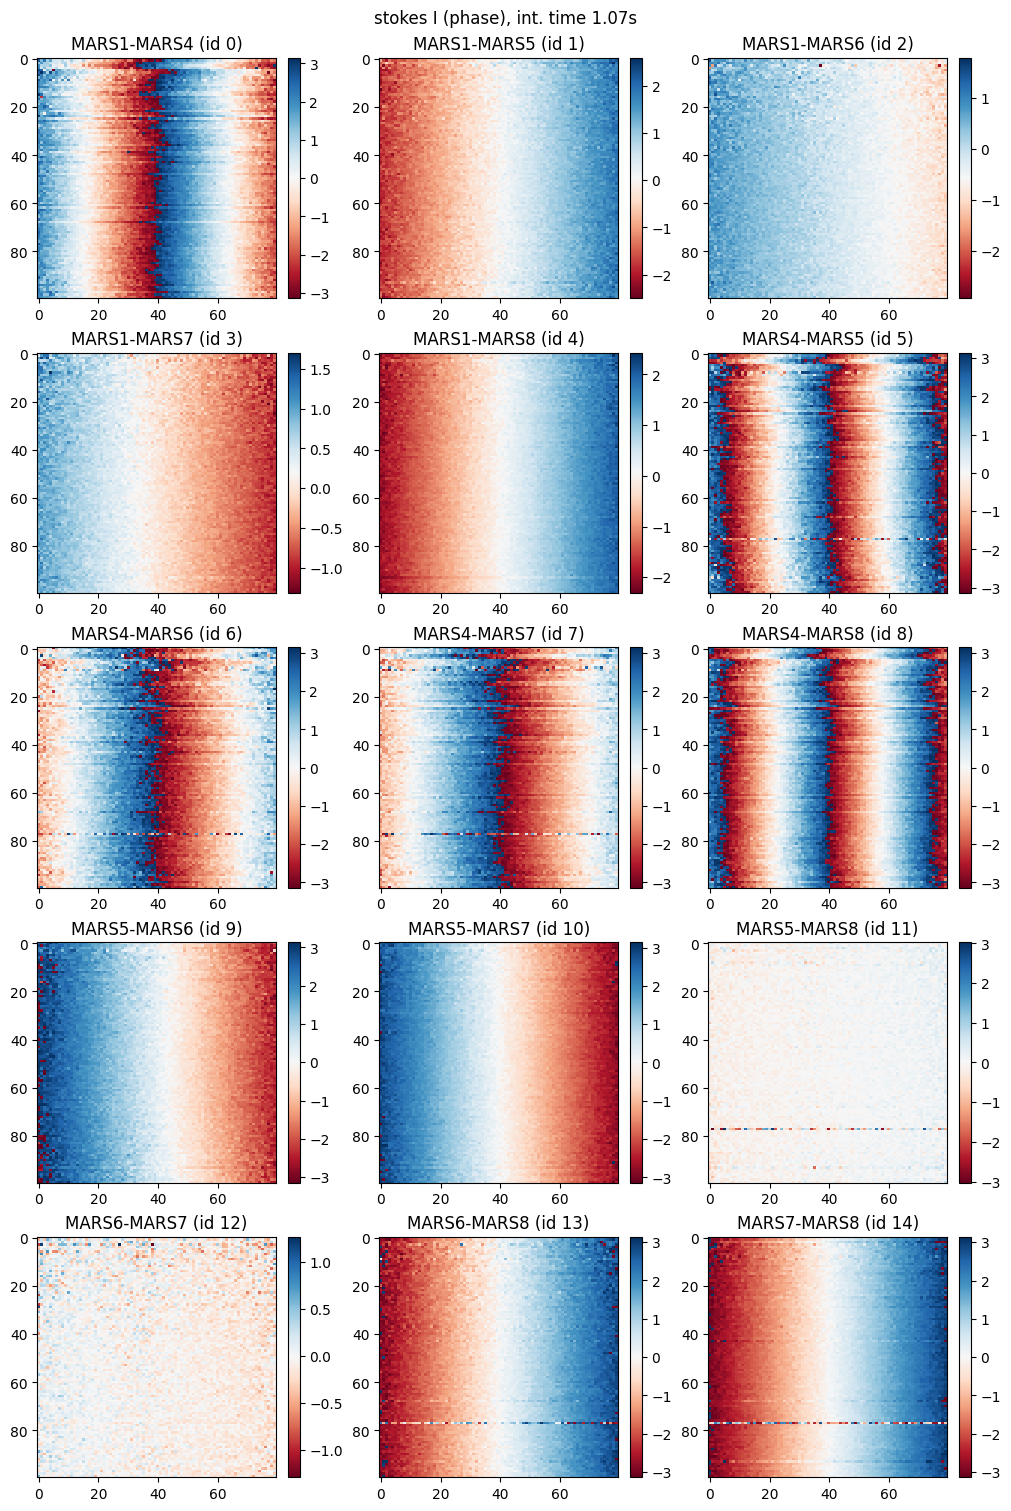

In [18]:
#generate aligned phase plots for each baseline with fitted taus

antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(5,3, constrained_layout=True)
fig.set_size_inches(10,15)
ax=np.ravel(ax)

pnum=0
print(n_blines)
plt.suptitle(f"stokes I (phase), int. time {T_SPECTRA*acclen:4.2f}s")
x = np.arange(nchans)
phased_vis = np.empty_like(multi_vis[:,:,:])
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            if i==0:
                tau1=0
            else:
                tau1 = taus_unwrapped[:,i-1]
            tau2 = taus_unwrapped[:,j-1]
            rel_delay = tau1-tau2
            ax[pnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {pnum})")
            phased_vis[pnum,:,:] = multi_vis[pnum,:,:]*np.exp(-2j*np.pi*freqs_normalized[None,:]*rel_delay[:,None])
            img=ax[pnum].imshow(np.angle(phased_vis[pnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
            cbar=plt.colorbar(img,ax=ax[pnum])
            pnum+=1
# plt.tight_layout()

(80, 15)
[[0.01765777 0.01260055 0.01139329 0.00746741 0.00756121 0.02341125
  0.02399306 0.01665483 0.01830146 0.01240721 0.01102842 0.01068111
  0.01302956 0.01418739 0.00847627]]


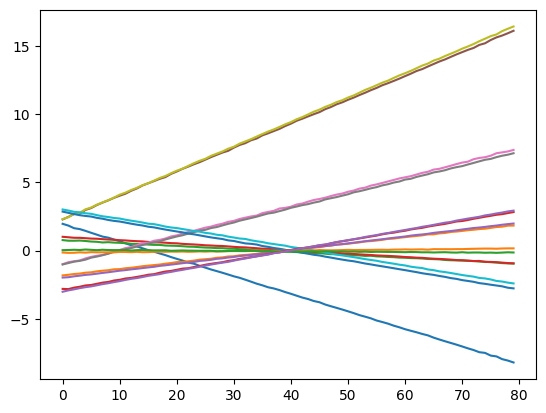

In [19]:
#phased vis is now the array of interest

#take average across time once aligned to boost SNR
avg_multi_vis = np.mean(phased_vis,axis=1)
# avg_multi_vis = np.median(phased_vis,axis=1)

#now have very clean phase ramp with super low noise
avg_multi_vis = avg_multi_vis.T.copy()
plt.plot(np.unwrap(np.angle(avg_multi_vis),axis=0))
print(avg_multi_vis.shape)


#get that noise by fitting a line and getting std of residuals
noise_matrix_avg = np.zeros((1,n_blines),dtype='float64')
for bl in range(n_blines):
    y = np.unwrap(np.angle(avg_multi_vis[:,bl]))
    m, c = np.polyfit(x,y, 1)
    residual = y - (m*x + c)
    noise_matrix_avg[0,bl] = np.std(residual)
print(noise_matrix_avg)

In [ ]:
ntime2=1
nant=6
nbl=nant*(nant-1)//2

#can now just fit linearly using normal equations
data_matrix = np.unwrap(np.angle(avg_multi_vis),axis=0)
data_matrix = data_matrix.reshape(ntime2,nchans,nbl)

Ag = mt.get_grammian(nant)
print(data_matrix.shape)

AtA2,Atd2 = mt.get_AtA_Atd(data_matrix,
                            Ag,
                            noise_matrix_avg**2,
                            freqs_normalized,
                            nant,
                            nchans,
                            ntime2,
                            fit_constant=True)

AtA_inv2 = np.linalg.inv(AtA2)

mfit2 = AtA_inv2 @ Atd2
print(mfit2)
# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
tau_linear2 = mfit2[:ntime2 * bs]
phi_linear2 = mfit2[ntime2 * bs:]
errs_all = np.sqrt(np.diag(AtA_inv2))
print(tau_linear2)
print('test')

taus_fitted_all = tau_linear2[:, np.newaxis] + taus_unwrapped.T
taus_errs_all = errs[:nant-1]

(1, 80, 15)
Snu 69.31699653708051 Snu2 60.06057664324527
[-21435.16665727   7766.32569446  -3641.63571896  -4105.50437228
   8410.32260375  18577.99542293  -6729.48586828   3155.29690461
   3557.27911402  -7287.51963134]
[7.49587129 5.37833327 5.59825878 4.35631756 4.39884732 6.49489114
 4.66012392 4.85068112 3.77458566 3.8114361 ]
[-21435.16665727   7766.32569446  -3641.63571896  -4105.50437228
   8410.32260375]
test


In [21]:
# with h5py.File('finetiming_dump1.h5', 'a') as f:
#     ds = f.create_dataset(fname_data, data=taus_fitted_all)
#     ds.attrs['starting_specnum'] = pulse_start_spec_cut

In [22]:
print('test')

test
